In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline

In [ ]:
df = pd.read_csv('Ozono_Data.csv')

In [ ]:
print("Primeras filas del dataset cargado:")
display(df.head())

Primeras filas del dataset cargado:


,Date,Site ID,POC,Daily Max Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-03,80013001,2,0.006,Parts per million,6,Welby,12,71,44201,...,1554,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Colorado Department of Public Health And Envir...,POPULATION EXPOSURE,Y,NaN,5.0,NaN
1,2022-01-04,80013001,2,0.039,Parts per million,36,Welby,17,100,44201,...,1554,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Colorado Department of Public Health And Envir...,POPULATION EXPOSURE,Y,NaN,5.0,NaN
2,2022-01-05,80013001,2,0.022,Parts per million,20,Welby,17,100,44201,...,1554,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Colorado Department of Public Health And Envir...,POPULATION EXPOSURE,Y,NaN,5.0,NaN
3,2022-01-06,80013001,2,0.017,Parts per million,16,Welby,13,76,44201,...,1554,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Colorado Department of Public Health And Envir...,POPULATION EXPOSURE,Y,NaN,5.0,NaN
4,2022-01-13,80013001,2,0.001,Parts per million,1,Welby,3,18,44201,...,1554,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Colorado Department of Public Health And Envir...,POPULATION EXPOSURE,Y,NaN,5.0,NaN


In [ ]:
columna_y = 'Daily Max Ozone Concentration'
columna_x = 'Date'

In [ ]:
df_clean = df[[columna_x, columna_y]].dropna().copy()

In [ ]:
df_clean[columna_x] = pd.to_datetime(df_clean[columna_x])

In [ ]:
df_clean['Day_Index'] = (df_clean[columna_x] - df_clean[columna_x].min()).dt.days

In [ ]:
print(f"Total de registros limpios para el análisis: {len(df_clean)}")

Total de registros limpios para el análisis: 29847


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = df_clean[['Day_Index']]
y = df_clean[columna_y]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = modelo.predict(X_test)

print(f"\n--- Resultados del Modelo ---")
print(f"Pendiente (Cambio diario de ozono): {modelo.coef_[0]:.6f}")
print(f"Intercepto: {modelo.intercept_:.2f}")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² (Coeficiente de Determinación): {r2_score(y_test, y_pred):.4f}")


--- Resultados del Modelo ---
Pendiente (Cambio diario de ozono): -0.000003
Intercepto: 0.05
Error Cuadrático Medio (MSE): 0.0001
R² (Coeficiente de Determinación): 0.0041


In [ ]:
sorted_idx = X_test['Day_Index'].argsort()
X_test_sorted = X_test.iloc[sorted_idx]
y_test_sorted = y_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

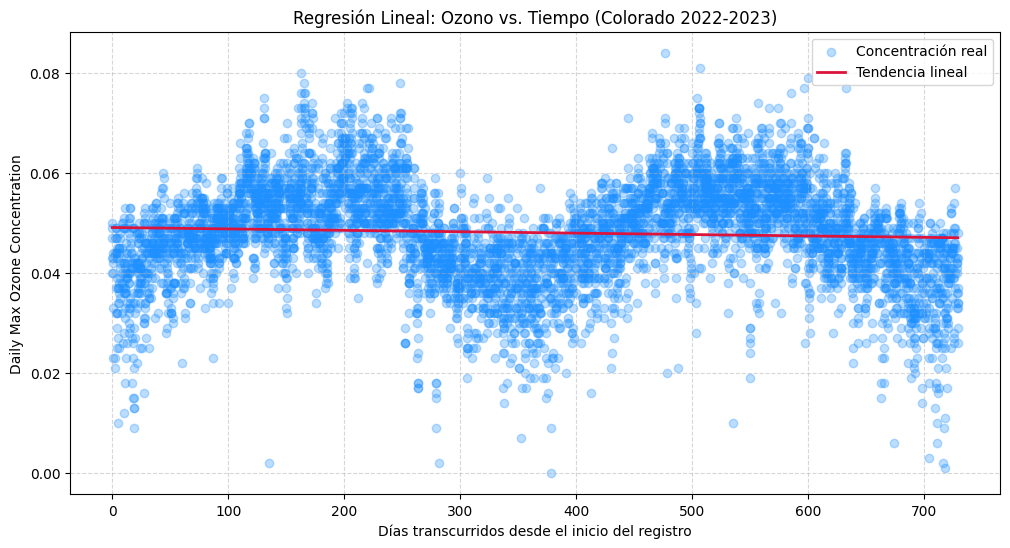

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(X_test_sorted['Day_Index'], y_test_sorted, color='dodgerblue', alpha=0.3, label='Concentración real')
plt.plot(X_test_sorted['Day_Index'], y_pred_sorted, color='crimson', linewidth=2, label='Tendencia lineal')
plt.xlabel('Días transcurridos desde el inicio del registro')
plt.ylabel('Daily Max Ozone Concentration')
plt.title('Regresión Lineal: Ozono vs. Tiempo (Colorado 2022-2023)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()